<a href="https://colab.research.google.com/github/ProjetosNanos/NanoAgenteSimples/blob/main/NanoAgentes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain -q
!pip install langchain-core -q
!pip install langchain-community -q
!pip install langchain-ollama -q
!pip install langgraph -q

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage

#Define o schema do estado
class State(TypedDict):
    messages: Annotated[list[HumanMessage], add_messages]

#Define a Funcao do no de entrada
def entrada_usuario(state: State) -> State:
    pergunta = input("Pergunta: ")
    print(f"Entrada recebida: {pergunta}")
    if isinstance(pergunta, str) and pergunta.strip():
        #HumanMessage objeto
        return {"messages": [HumanMessage(content=pergunta)]}
    else:
        raise ValueError("A pergunta deve ser uma string nao vazia")

def processamento_resposta(state: State) -> State:
    pergunta = state["messages"][-1].content
    print(f"Estado da funcao de processamento: {state}")

    if isinstance(pergunta, str) and pergunta.strip():
        #Resposta simulada
        resposta = f"A resposta para a sua pergunta '{pergunta}' e: [resposta simulada]"
        print(f"Resposta gerada: {resposta}")
        return {"messages": [resposta]}
    else:
        raise ValueError("A pergunta deve ser uma string nao vazia")

def saida_resposta(state: State) -> State:
    print(f"Estado na funcao de saida: {state}")
    print(state["messages"][-1])
    return state

# criando o estado do grafo
grafo = StateGraph(State)

# Adicionando nos ao grafo
grafo.add_node("entrada", entrada_usuario)
grafo.add_node("processamento", processamento_resposta)
grafo.add_node("saida", saida_resposta)

# definindo as conexoes entre os nos
grafo.add_edge(START, "entrada")
grafo.add_edge("entrada", "processamento")
grafo.add_edge("processamento", "saida")
grafo.add_edge("saida", END)

#Compilando o grafo
compiled = grafo.compile()

# implementando a interacao com um loop
while True:
    compiled.invoke({"messages": [HumanMessage(content="Como posso te ajudar hoje?")]})
    continuar = input("Voce deseja fazer outra pergunta? (sim/nao): ")
    if continuar.lower() != "sim":
      break

Pergunta: opa tudo bom joao
Entrada recebida: opa tudo bom joao
Estado da funcao de processamento: {'messages': [HumanMessage(content='Como posso te ajudar hoje?', additional_kwargs={}, response_metadata={}, id='be24a68f-2f87-4bdd-98ef-c115be8f0530'), HumanMessage(content='opa tudo bom joao', additional_kwargs={}, response_metadata={}, id='9290a7b0-4d8f-44c8-845f-084ce962e104')]}
Resposta gerada: A resposta para a sua pergunta 'opa tudo bom joao' e: [resposta simulada]
Estado na funcao de saida: {'messages': [HumanMessage(content='Como posso te ajudar hoje?', additional_kwargs={}, response_metadata={}, id='be24a68f-2f87-4bdd-98ef-c115be8f0530'), HumanMessage(content='opa tudo bom joao', additional_kwargs={}, response_metadata={}, id='9290a7b0-4d8f-44c8-845f-084ce962e104'), HumanMessage(content="A resposta para a sua pergunta 'opa tudo bom joao' e: [resposta simulada]", additional_kwargs={}, response_metadata={}, id='71ecc952-c3a1-49ad-b5a4-502bbc9754c6')]}
content="A resposta para a su

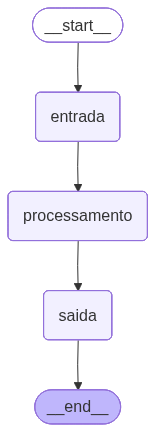

In [ ]:
from IPython.display import Image

Image(compiled.get_graph().draw_mermaid_png())